In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 스타일 설정
sns.set_theme(style="whitegrid")

# 1. 데이터 로드 (파일 경로 확인 필수!)
# 보통 data/hosp/ 안에 있습니다.
try:
    diag = pd.read_csv('../data/hosp/diagnoses_icd.csv.gz')
    dict_diag = pd.read_csv('../data/hosp/d_icd_diagnoses.csv.gz')
except FileNotFoundError:
    # 혹시 압축이 풀려있다면 .gz 제거
    diag = pd.read_csv('../data/hosp/diagnoses_icd.csv')
    dict_diag = pd.read_csv('../data/hosp/d_icd_diagnoses.csv')

print("진단 기록 수:", len(diag))
print("진단 코드 사전 수:", len(dict_diag))
display(diag.head())

진단 기록 수: 4506
진단 코드 사전 수: 109775


,subject_id,hadm_id,seq_num,icd_code,icd_version
0,10035185,22580999,3,4139,9
1,10035185,22580999,10,V707,9
2,10035185,22580999,1,41401,9
3,10035185,22580999,9,3899,9
4,10035185,22580999,11,V8532,9


In [2]:
# 2. 진단 코드와 실제 병명 합치기 (Left Join)
# 기준: icd_code, icd_version
df_diag = pd.merge(diag, dict_diag, on=['icd_code', 'icd_version'], how='left')

# 병명이 잘 붙었는지 확인
display(df_diag[['subject_id', 'icd_code', 'long_title']].head())

,subject_id,icd_code,long_title
0,10035185,4139,Other and unspecified angina pectoris
1,10035185,V707,Examination of participant in clinical trial
2,10035185,41401,Coronary atherosclerosis of native coronary ar...
3,10035185,3899,Unspecified hearing loss
4,10035185,V8532,"Body Mass Index 32.0-32.9, adult"


=== Top 10 Diagnoses ===
long_title
Unspecified essential hypertension             68
Hyperlipidemia, unspecified                    57
Acute kidney failure, unspecified              56
Other and unspecified hyperlipidemia           55
Hypothyroidism, unspecified                    47
Obesity, unspecified                           43
Anemia, unspecified                            41
Long term (current) use of insulin             37
Urinary tract infection, site not specified    36
Personal history of nicotine dependence        35
Name: count, dtype: int64


/var/folders/7g/yfw3s_751r3_mltv2zk6glnh0000gn/T/ipykernel_37819/2162453140.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_diseases.values, y=top_10_diseases.index, palette='viridis')


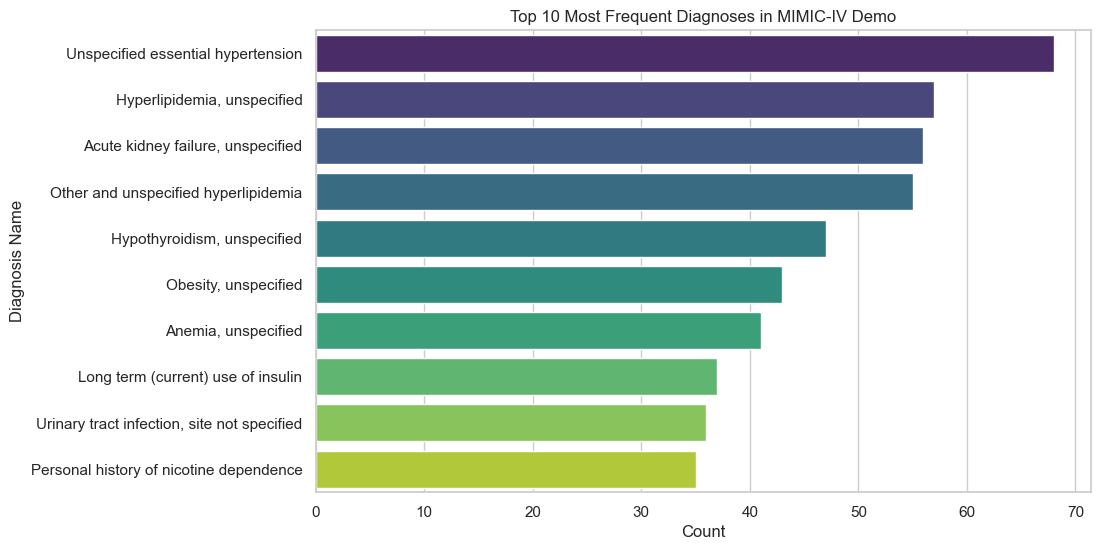

In [3]:
# 3. 가장 많이 등장한 상위 10개 진단명 찾기
top_10_diseases = df_diag['long_title'].value_counts().head(10)

print("=== Top 10 Diagnoses ===")
print(top_10_diseases)

# 4. 시각화 (가로 막대 그래프)
plt.figure(figsize=(10, 6))
sns.barplot(x=top_10_diseases.values, y=top_10_diseases.index, palette='viridis')
plt.title('Top 10 Most Frequent Diagnoses in MIMIC-IV Demo')
plt.xlabel('Count')
plt.ylabel('Diagnosis Name')

# 이미지 저장 (나중에 리드미에 쓰기 위해!)
import os
os.makedirs('../images', exist_ok=True)
plt.savefig('../images/top_10_diagnoses.png', dpi=300, bbox_inches='tight')
plt.show()

선택된 환자 ID: 10014354
진단받은 질병 수: 447


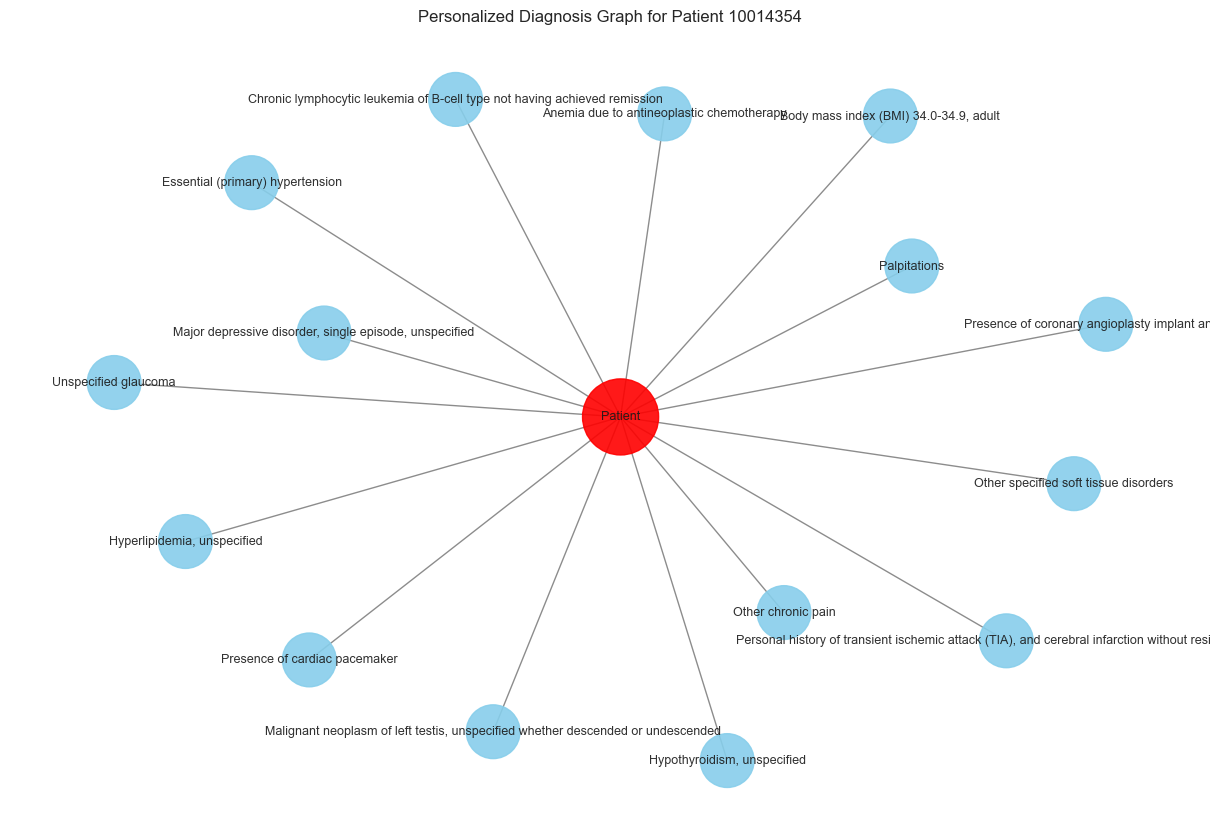

In [5]:
import networkx as nx

# 1. 진단 기록이 가장 많은 환자 1명 찾기 (샘플)
top_patient_id = df_diag['subject_id'].value_counts().idxmax()
patient_data = df_diag[df_diag['subject_id'] == top_patient_id]

print(f"선택된 환자 ID: {top_patient_id}")
print(f"진단받은 질병 수: {len(patient_data)}")

# 2. 그래프 생성 (GraphCare 스타일: 환자 중심 연결)
G = nx.Graph()

# 중심 노드: 환자 (Red)
G.add_node('Patient', color='red', size=3000)

# 주변 노드: 질병들 (Blue)
# 너무 많으면 그래프가 지저분하니까 상위 15개만 그림
diseases = patient_data['long_title'].unique()[:15]

for disease in diseases:
    G.add_node(disease, color='skyblue', size=1500)
    G.add_edge('Patient', disease)

# 3. 그래프 시각화
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, k=0.5)  # k는 노드 간 거리 조절

# 노드 그리기
node_colors = [nx.get_node_attributes(G, 'color')[node] for node in G.nodes()]
node_sizes = [nx.get_node_attributes(G, 'size')[node] for node in G.nodes()]

nx.draw(G, pos, 
        with_labels=True, 
        node_color=node_colors, 
        node_size=node_sizes, 
        font_size=9, 
        edge_color='gray', 
        alpha=0.9)

plt.title(f"Personalized Diagnosis Graph for Patient {top_patient_id}")

# 이미지 저장
plt.savefig('../images/patient_graph_sample.png', dpi=300, bbox_inches='tight')
plt.show()